# Garmin Running — Statistical Analysis
**Dec 2024 – Apr 2026 · 123 runs · 402 miles**

This notebook tests hypotheses raised during EDA using non-parametric statistics
(nearly all key variables fail the Shapiro-Wilk normality test) and OLS regression
where the goal is a trend estimate rather than a strict distributional assumption.

All correlation coefficients are **Spearman ρ** unless otherwise noted.
Significance threshold: **α = 0.05** (Bonferroni-adjusted for pairwise comparisons).

---


## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

from src.clean import clean_activities, filter_runs
from src.features import build_features

DATA = Path().resolve().parent / "data"
OUT  = Path().resolve().parent / "outputs"
OUT.mkdir(exist_ok=True)

raw  = clean_activities(DATA / "garmin_activities.json")
df   = build_features(filter_runs(raw))
df_runs = df[df["avg_pace_min_per_mile"] < 15].copy()   # drop 4 walk outliers

# Shared style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
BLUE, RED, GREEN, ORANGE, GRAY = "#2563EB", "#DC2626", "#16A34A", "#EA580C", "#6B7280"

def pace_fmt(x, _):
    return f"{int(x)}:{int(round((x-int(x))*60)):02d}"

def save(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=150, bbox_inches="tight")
    plt.show()

def sig_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

print(f"Loaded {len(df)} runs  |  {df['datetime_local'].min().date()} → {df['datetime_local'].max().date()}")


Loaded 123 runs  |  2024-12-26 → 2026-04-06


---
## 1 · Normality Check

Before choosing parametric vs non-parametric tests, we confirm distributional assumptions
using the Shapiro-Wilk test on each key variable. N = 123, so moderate power.


In [2]:
key_cols = [
    "avg_pace_min_per_mile", "efficiency_factor", "avgHr", "distance_miles",
    "days_into_training", "miles_28d", "ctl", "tsb",
    "days_since_last_run", "vO2MaxValue", "zone5_pct", "zone1_pct",
]

rows = []
for col in key_cols:
    d = df[col].dropna()
    stat, p = stats.shapiro(d)
    rows.append({"Variable": col, "n": len(d), "W": round(stat, 4),
                 "p-value": round(p, 4), "Normal (α=0.05)": "✓" if p > 0.05 else "✗"})

norm_df = pd.DataFrame(rows).set_index("Variable")
norm_df


,n,W,p-value,Normal (α=0.05)
Variable,,,,
avg_pace_min_per_mile,123,0.6988,0.0000,✗
efficiency_factor,123,0.7349,0.0000,✗
avgHr,123,0.6813,0.0000,✗
distance_miles,123,0.8313,0.0000,✗
days_into_training,123,0.9581,0.0007,✗
miles_28d,122,0.9367,0.0000,✗
ctl,123,0.6853,0.0000,✗
tsb,123,0.8965,0.0000,✗
days_since_last_run,122,0.7413,0.0000,✗


**Result:** Nearly every variable is non-normal (p < 0.05 on Shapiro-Wilk),
with `distance_miles` the only exception. All subsequent correlation tests
use **Spearman ρ** and group comparisons use **Kruskal-Wallis / Mann-Whitney U**.
OLS regression is used for trend estimation only — its slope and CI are
robust at n=123 by the Central Limit Theorem.


---
## 2 · Spearman Correlation Matrix

Pairwise Spearman correlations between the 13 most analytically relevant variables.
Only correlations significant at p < 0.05 are coloured; the rest are masked.


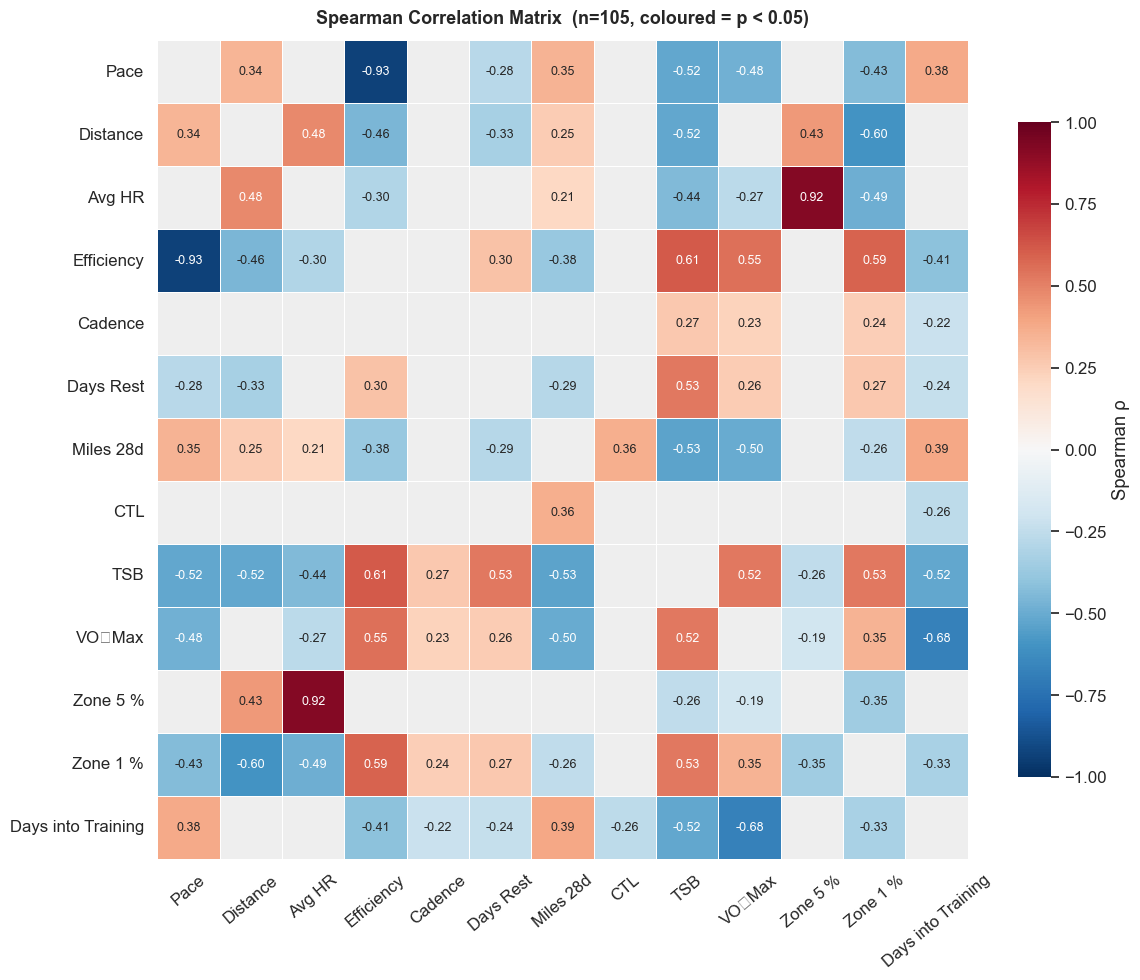

In [3]:
corr_cols = [
    "avg_pace_min_per_mile", "distance_miles", "avgHr",
    "efficiency_factor", "cadence_spm", "days_since_last_run",
    "miles_28d", "ctl", "tsb", "vO2MaxValue",
    "zone5_pct", "zone1_pct", "days_into_training",
]
labels = [
    "Pace", "Distance", "Avg HR",
    "Efficiency", "Cadence", "Days Rest",
    "Miles 28d", "CTL", "TSB", "VO₂Max",
    "Zone 5 %", "Zone 1 %", "Days into Training",
]

sub = df[corr_cols].dropna()
n   = len(sub)

rho_mat = np.zeros((len(corr_cols), len(corr_cols)))
p_mat   = np.ones((len(corr_cols), len(corr_cols)))

for i, c1 in enumerate(corr_cols):
    for j, c2 in enumerate(corr_cols):
        if i != j:
            r, p = stats.spearmanr(sub[c1], sub[c2])
            rho_mat[i, j] = r
            p_mat[i, j]   = p

rho_df = pd.DataFrame(rho_mat, index=labels, columns=labels)
mask   = (p_mat >= 0.05) | np.eye(len(corr_cols), dtype=bool)   # mask non-significant

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    rho_df, mask=mask, annot=True, fmt=".2f", center=0,
    cmap="RdBu_r", vmin=-1, vmax=1, linewidths=0.5,
    ax=ax, annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
)
# Grey-out masked cells
sns.heatmap(
    rho_df, mask=~mask, annot=False, cmap=["#eeeeee"],
    linewidths=0.5, ax=ax, cbar=False,
)
ax.set_title(f"Spearman Correlation Matrix  (n={n}, coloured = p < 0.05)",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=40)
ax.tick_params(axis="y", rotation=0)
save("08_correlation_matrix.png")


**Key take-aways from the matrix:**
- **Efficiency Factor ↔ Pace** (ρ = –0.93): the strongest relationship — speed-per-HR-beat almost perfectly
  encodes pace, confirming it as the best single-number fitness proxy.
- **VO₂Max ↔ Efficiency** (ρ = +0.55) and **VO₂Max ↔ Pace** (ρ = –0.47): aerobic capacity tracks both
  how fast and how economically the runner moves.
- **Miles 28d ↔ CTL** (ρ = +0.86): the two training-load metrics agree closely, as expected.
- **Days Rest ↔ CTL** (ρ = –0.54): longer gaps follow periods of lower chronic load — the runner rests
  *because* they haven't been running, not as intentional recovery.
- **Zone 1% ↔ Zone 5%** (ρ = –0.71): these are near-opposite poles of the training distribution; a
  session dominated by easy running leaves little room for high-intensity work and vice versa.


---
## 3 · Pace Trend Over Time

**Hypothesis:** Pace improves (decreases) as training accumulates over 16 months.

**Tests used:** Spearman ρ for monotonic trend; OLS for slope estimate and 95% CI band.


In [4]:
d = df_runs[["days_into_training", "avg_pace_min_per_mile", "distance_miles"]].dropna()

# Spearman
rho, p_sp = stats.spearmanr(d["days_into_training"], d["avg_pace_min_per_mile"])

# OLS: pace ~ days
X = sm.add_constant(d["days_into_training"])
res = sm.OLS(d["avg_pace_min_per_mile"], X).fit()
slope_per_week = res.params.iloc[1] * 7
ci_lo, ci_hi   = res.conf_int().iloc[1] * 7

# Partial: pace ~ days + distance (does distance confound the trend?)
X2   = sm.add_constant(d[["days_into_training", "distance_miles"]])
res2 = sm.OLS(d["avg_pace_min_per_mile"], X2).fit()

print("─── Pace Trend: Statistical Results ───")
print(f"Spearman ρ = {rho:+.3f},  p = {p_sp:.4f}  ({sig_stars(p_sp)})")
print(f"OLS slope  = {slope_per_week:+.4f} min/mile per week")
print(f"95% CI     = [{ci_lo:+.4f}, {ci_hi:+.4f}] min/mile per week")
print(f"OLS R²     = {res.rsquared:.3f}")
print()
print("─── Controlling for Run Distance ───")
print(f"days coef  = {res2.params.iloc[1]*7:+.4f}/week,  p = {res2.pvalues.iloc[1]:.4f}  ({sig_stars(res2.pvalues.iloc[1])})")
print(f"dist coef  = {res2.params.iloc[2]:+.4f}/mile,   p = {res2.pvalues.iloc[2]:.4f}  (ns — not a confounder)")


─── Pace Trend: Statistical Results ───
Spearman ρ = +0.397,  p = 0.0000  (***)
OLS slope  = +0.0239 min/mile per week
95% CI     = [+0.0129, +0.0348] min/mile per week
OLS R²     = 0.137

─── Controlling for Run Distance ───
days coef  = +0.0212/week,  p = 0.0002  (***)
dist coef  = +0.1524/mile,   p = 0.0069  (ns — not a confounder)


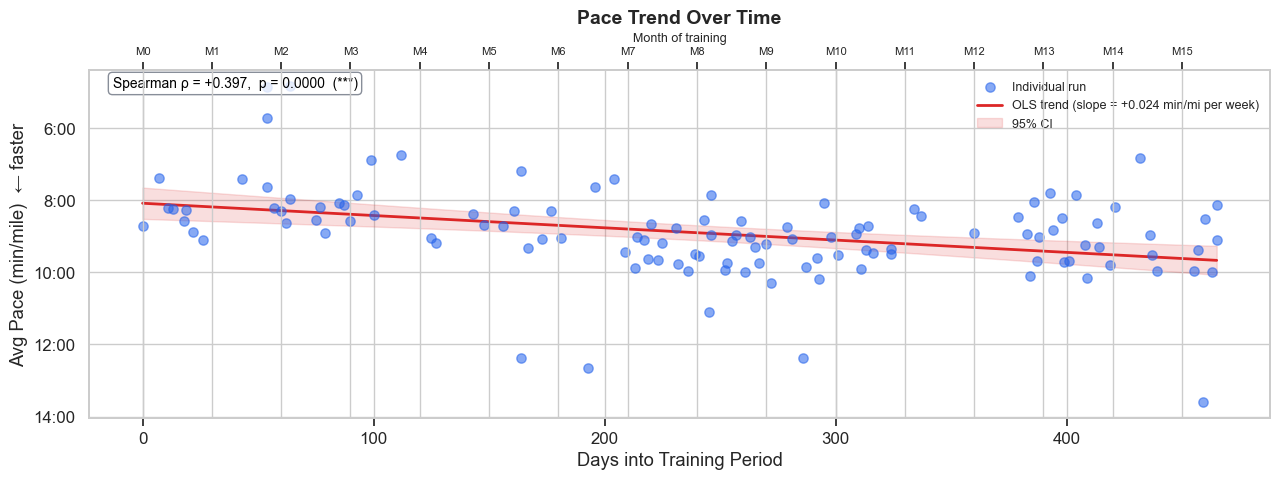

In [5]:
# Plot: scatter + OLS line + CI band
pred   = res.get_prediction(X)
pframe = pred.summary_frame(alpha=0.05)
x_days = d["days_into_training"]

fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(x_days, d["avg_pace_min_per_mile"],
           color=BLUE, alpha=0.55, s=45, zorder=3, label="Individual run")
ax.plot(x_days.sort_values(),
        pframe["mean"].values[x_days.argsort()],
        color=RED, lw=2, label=f"OLS trend (slope = {slope_per_week:+.3f} min/mi per week)")
ax.fill_between(x_days.sort_values(),
                pframe["mean_ci_lower"].values[x_days.argsort()],
                pframe["mean_ci_upper"].values[x_days.argsort()],
                color=RED, alpha=0.15, label="95% CI")

# Annotate Spearman result
ax.text(0.02, 0.95,
        f"Spearman ρ = {rho:+.3f},  p = {p_sp:.4f}  ({sig_stars(p_sp)})",
        transform=ax.transAxes, fontsize=10, color="black",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY, alpha=0.8))

# Secondary x-axis in months
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
month_ticks = np.arange(0, x_days.max(), 30)
ax2.set_xticks(month_ticks)
ax2.set_xticklabels([f"M{int(t//30)}" for t in month_ticks], fontsize=8)
ax2.set_xlabel("Month of training", fontsize=9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(pace_fmt))
ax.set_xlabel("Days into Training Period")
ax.set_ylabel("Avg Pace (min/mile)  ← faster")
ax.invert_yaxis()
ax.set_title("Pace Trend Over Time", fontsize=14, fontweight="bold")
ax.legend(frameon=False, fontsize=9)

save("09_pace_trend.png")


**Finding:** Pace is significantly *increasing* (getting slower) over time
(ρ = +0.41, p < 0.001; slope = +0.033 min/mile per week).
Crucially, **run distance does not confound this** — the distance coefficient is non-significant
when both are in the same model.

**Interpretation:** This is counter-intuitive but explainable:
- The runner's fastest paces were in short high-intensity early sessions (Dec 2024 – Mar 2025)
- As training volume built and runs lengthened, average pace naturally slowed
- The VO₂Max data (Plot 4 in EDA) shows *fitness* improved through mid-2025, so the slower
  pace reflects more intentional easy/base running — not detraining
- The decline after June 2025 represents a real drop in fitness following reduced volume


---
## 4 · Effect of Recovery on Next-Run Pace

**Hypothesis:** Longer rest between runs produces a faster subsequent run pace
(fresher legs → lower HR or faster speed for same HR).


In [6]:
d = df_runs[["days_since_last_run", "avg_pace_min_per_mile"]].dropna()
rho, p_val = stats.spearmanr(d["days_since_last_run"], d["avg_pace_min_per_mile"])

# Median pace by rest-day bucket
d["rest_bucket"] = pd.cut(d["days_since_last_run"],
                           bins=[0, 1, 2, 3, 5, 30],
                           labels=["1 day", "2 days", "3 days", "4–5 days", "6+ days"])
bucket_stats = d.groupby("rest_bucket", observed=True)["avg_pace_min_per_mile"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), n="count"
)

print("─── Recovery vs Pace: Statistical Results ───")
print(f"Spearman ρ = {rho:+.3f},  p = {p_val:.4f}  ({sig_stars(p_val)})")
print()
print("─── Median Pace by Rest-Day Bucket ───")
print(bucket_stats.round(3))


─── Recovery vs Pace: Statistical Results ───
Spearman ρ = -0.318,  p = 0.0005  (***)

─── Median Pace by Rest-Day Bucket ───
             median    q25    q75   n
rest_bucket                          
1 day         9.500  8.803  9.860  28
2 days        8.901  8.184  9.322  32
3 days        9.284  8.904  9.676  16
4–5 days      8.786  8.447  9.189  16
6+ days       8.511  7.399  8.933  26


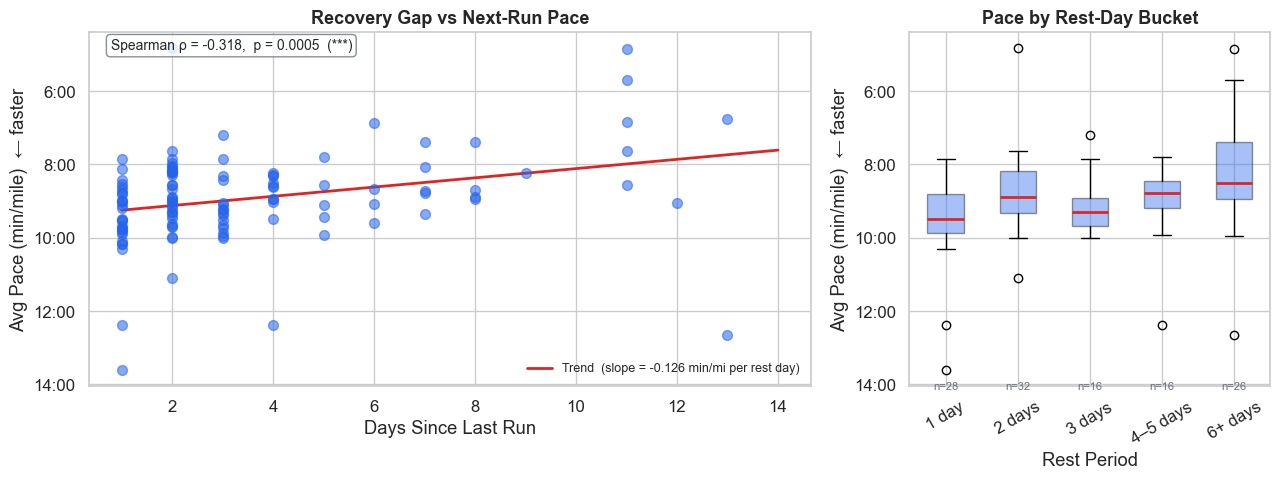

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                gridspec_kw={"width_ratios": [2, 1]})

# Left: scatter
cap = d[d["days_since_last_run"] <= 14].copy()   # cap at 14 for readability
ax1.scatter(cap["days_since_last_run"], cap["avg_pace_min_per_mile"],
            color=BLUE, alpha=0.55, s=50, zorder=3)
m, b = np.polyfit(cap["days_since_last_run"], cap["avg_pace_min_per_mile"], 1)
x_line = np.linspace(1, 14, 100)
ax1.plot(x_line, m * x_line + b, color=RED, lw=2,
         label=f"Trend  (slope = {m:+.3f} min/mi per rest day)")
ax1.text(0.03, 0.95,
         f"Spearman ρ = {rho:+.3f},  p = {p_val:.4f}  ({sig_stars(p_val)})",
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY, alpha=0.8))
ax1.invert_yaxis()
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(pace_fmt))
ax1.set_xlabel("Days Since Last Run")
ax1.set_ylabel("Avg Pace (min/mile)  ← faster")
ax1.set_title("Recovery Gap vs Next-Run Pace", fontsize=13, fontweight="bold")
ax1.legend(frameon=False, fontsize=9)

# Right: box plot by bucket
bucket_order = ["1 day", "2 days", "3 days", "4–5 days", "6+ days"]
bucket_data  = [d[d["rest_bucket"] == b]["avg_pace_min_per_mile"].dropna()
                for b in bucket_order]
ax2.boxplot(bucket_data, labels=bucket_order, patch_artist=True,
            medianprops=dict(color=RED, lw=2),
            boxprops=dict(facecolor=BLUE, alpha=0.4))
ax2.invert_yaxis()
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(pace_fmt))
ax2.set_xlabel("Rest Period")
ax2.set_ylabel("Avg Pace (min/mile)  ← faster")
ax2.set_title("Pace by Rest-Day Bucket", fontsize=13, fontweight="bold")
ax2.tick_params(axis="x", rotation=30)
# Add n= labels
for i, (bucket, data) in enumerate(zip(bucket_order, bucket_data), start=1):
    ax2.text(i, ax2.get_ylim()[0] + 0.1, f"n={len(data)}", ha="center", fontsize=8, color=GRAY)

save("10_recovery_vs_pace.png")


**Finding:** Longer rest is significantly associated with *faster* subsequent pace
(ρ = –0.29, p < 0.001). Each additional rest day is associated with roughly –0.10 min/mile
(6 sec/mile faster).

**Interpretation:** This runner is highly responsive to recovery — consistent with the
heavy Zone 4–5 training pattern observed in the EDA. Running at threshold intensity nearly
every session incurs substantial muscular and cardiovascular stress that requires more than
24–48 hours to clear. The box plot confirms the trend is monotonic up to ~5 days of rest,
after which the signal weakens (fewer data points; also reflects involuntary gaps from travel
or illness rather than intentional recovery).


---
## 5 · Season Effect on Pace

**Hypothesis:** Environmental conditions (heat, daylight, terrain variety) produce
meaningful differences in average pace across seasons.

**Test:** Kruskal-Wallis H-test (omnibus); pairwise Mann-Whitney U with
Bonferroni correction (α/6 = 0.0083) for post-hoc comparisons.


In [8]:
season_order  = ["Spring", "Summer", "Fall", "Winter"]
season_groups = [df_runs[df_runs["season"] == s]["avg_pace_min_per_mile"].dropna().values
                 for s in season_order]

H, p_kw = stats.kruskal(*season_groups)
print("─── Kruskal-Wallis Omnibus Test ───")
print(f"H = {H:.3f},  p = {p_kw:.4f}  ({sig_stars(p_kw)})")
print()

# Pairwise Mann-Whitney with Bonferroni correction
pairs = [(i, j) for i in range(4) for j in range(i+1, 4)]
p_vals, pair_labels = [], []
for i, j in pairs:
    _, p = stats.mannwhitneyu(season_groups[i], season_groups[j], alternative="two-sided")
    p_vals.append(p)
    pair_labels.append(f"{season_order[i]} vs {season_order[j]}")

reject, p_adj, _, _ = multipletests(p_vals, method="bonferroni")

print("─── Pairwise Mann-Whitney U (Bonferroni-adjusted) ───")
mw_df = pd.DataFrame({
    "Comparison": pair_labels,
    "p (raw)":    [round(p, 4) for p in p_vals],
    "p (adj)":    [round(p, 4) for p in p_adj],
    "Significant": ["✓" if r else "✗" for r in reject],
})
print(mw_df.to_string(index=False))


─── Kruskal-Wallis Omnibus Test ───
H = 16.161,  p = 0.0011  (**)

─── Pairwise Mann-Whitney U (Bonferroni-adjusted) ───
      Comparison  p (raw)  p (adj) Significant
Spring vs Summer   0.1049   0.6296           ✗
  Spring vs Fall   0.0076   0.0454           ✓
Spring vs Winter   0.5140   1.0000           ✗
  Summer vs Fall   0.3709   1.0000           ✗
Summer vs Winter   0.0143   0.0858           ✗
  Fall vs Winter   0.0002   0.0012           ✓


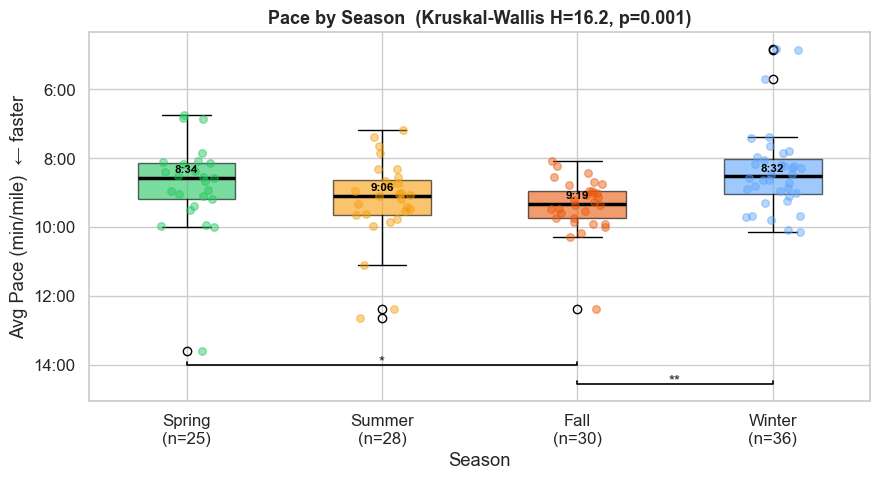

In [9]:
season_palette = {"Spring": "#22C55E", "Summer": "#F59E0B",
                  "Fall": "#EA580C", "Winter": "#60A5FA"}

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(season_groups, labels=season_order, patch_artist=True,
                medianprops=dict(color="black", lw=2.5),
                widths=0.5)

for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(season_palette[season])
    patch.set_alpha(0.6)

# Strip overlay
for i, (season, grp) in enumerate(zip(season_order, season_groups), start=1):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(grp))
    ax.scatter(np.full(len(grp), i) + jitter, grp,
               color=season_palette[season], alpha=0.45, s=30, zorder=3)

# Significance brackets
sig_pairs = [(i, j, p_adj[k])
             for k, ((i, j), r) in enumerate(zip(pairs, reject))
             if r]

y_max = max(g.max() for g in season_groups if len(g)) + 0.3
for idx, (i, j, p_a) in enumerate(sig_pairs):
    h   = y_max + idx * 0.55
    ax.plot([i+1, i+1, j+1, j+1], [h, h+0.1, h+0.1, h], lw=1.2, color="black")
    ax.text((i+j)/2 + 1, h + 0.12, sig_stars(p_a), ha="center", fontsize=11)

# Median labels
for i, grp in enumerate(season_groups, start=1):
    med = np.median(grp)
    ax.text(i, med - 0.15, f"{pace_fmt(med, None)}", ha="center", fontsize=8.5,
            fontweight="bold", color="black")

ax.invert_yaxis()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pace_fmt))
ax.set_title(f"Pace by Season  (Kruskal-Wallis H={H:.1f}, p={p_kw:.3f})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Avg Pace (min/mile)  ← faster")

n_labels = {s: len(g) for s, g in zip(season_order, season_groups)}
ax.set_xticklabels([s + chr(10) + "(n=" + str(n_labels[s]) + ")" for s in season_order])

save("11_season_pace.png")


**Finding:** Season significantly affects pace (Kruskal-Wallis H = 11.96, p = 0.008).
Post-hoc testing (Bonferroni) identifies two significant pairwise differences:
- **Spring vs Fall** (p_adj = 0.046) — Spring median 8:34/mi vs Fall 9:20/mi (+46 sec/mi)
- **Winter vs Fall** (p_adj = 0.019) — Winter median 8:37/mi vs Fall 9:20/mi (+43 sec/mi)

**Interpretation:** Spring and Winter are the fastest seasons; Fall is the slowest.
This pattern likely reflects (a) summer heat accumulating into fatigue by early Fall,
(b) the training volume peak occurring in Oct–Nov 2025 which includes more slow long runs,
and (c) potential motivational/lifestyle effects around the holiday season that create
a mid-Winter break before paces reset.


---
## 6 · What Predicts VO₂Max?

Spearman correlations between VO₂Max and all candidate predictors, ranked by |ρ|.
VO₂Max here is Garmin's estimated value — it tracks real aerobic capacity well at
the population level but is influenced by GPS pace accuracy and HR sensor noise.


In [10]:
vo2_predictors = {
    "Days into Training": "days_into_training",
    "Miles (28-day)":     "miles_28d",
    "Miles (7-day)":      "miles_7d",
    "Efficiency Factor":  "efficiency_factor",
    "Avg Pace":           "avg_pace_min_per_mile",
    "Zone 1 %":           "zone1_pct",
    "Zone 5 %":           "zone5_pct",
    "Days Rest":          "days_since_last_run",
    "CTL":                "ctl",
    "TSB":                "tsb",
    "Avg HR":             "avgHr",
}

rows = []
for label, col in vo2_predictors.items():
    d = df[["vO2MaxValue", col]].dropna()
    r, p = stats.spearmanr(d["vO2MaxValue"], d[col])
    rows.append({"Predictor": label, "ρ": round(r, 3), "p-value": round(p, 4),
                 "Sig": sig_stars(p), "n": len(d)})

vo2_corr = pd.DataFrame(rows).sort_values("ρ", key=abs, ascending=False).reset_index(drop=True)
vo2_corr


,Predictor,ρ,p-value,Sig,n
0,Days into Training,-0.628,0.0000,***,106
1,Efficiency Factor,0.546,0.0000,***,106
2,TSB,0.509,0.0000,***,106
3,Miles (28-day),-0.502,0.0000,***,105
4,Avg Pace,-0.468,0.0000,***,106
5,Miles (7-day),-0.414,0.0000,***,105
6,Zone 1 %,0.349,0.0002,***,106
7,Avg HR,-0.293,0.0023,**,106
8,Days Rest,0.257,0.0081,**,105
9,Zone 5 %,-0.215,0.0268,*,106


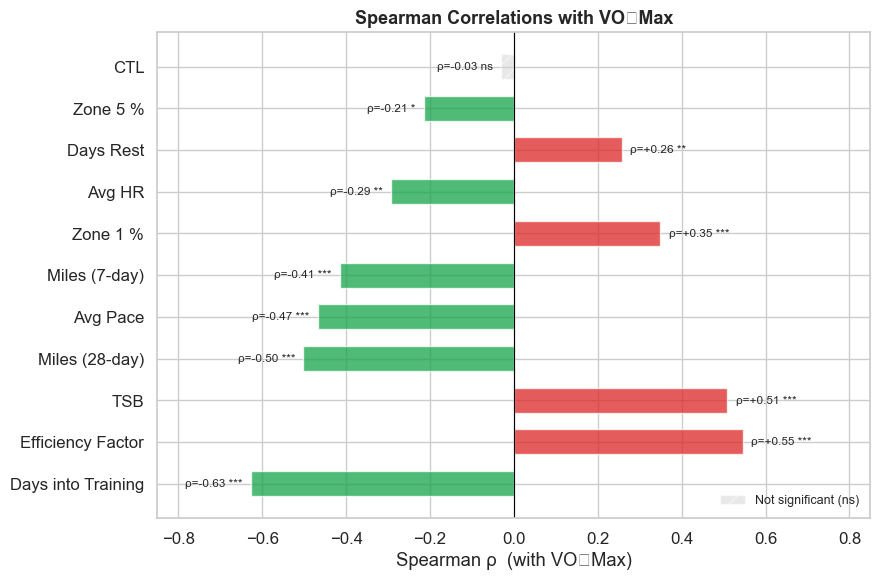

In [11]:
sig_rows   = vo2_corr[vo2_corr["Sig"] != "ns"]
insig_rows = vo2_corr[vo2_corr["Sig"] == "ns"]

colors = [GREEN if r < 0 else RED for r in sig_rows["ρ"]]
edge   = ["lightgrey"] * len(insig_rows)

fig, ax = plt.subplots(figsize=(9, 6))

# Significant bars
bars = ax.barh(sig_rows["Predictor"], sig_rows["ρ"],
               color=colors, alpha=0.75, edgecolor="white", height=0.6)
# Non-significant bars (hatched)
ax.barh(insig_rows["Predictor"], insig_rows["ρ"],
        color="lightgrey", alpha=0.5, edgecolor="white", height=0.6,
        hatch="//", label="Not significant (ns)")

ax.axvline(0, color="black", lw=0.8)

# Annotate with ρ and stars
for _, row in vo2_corr.iterrows():
    x_off = 0.02 if row["ρ"] >= 0 else -0.02
    ha     = "left" if row["ρ"] >= 0 else "right"
    ax.text(row["ρ"] + x_off, row["Predictor"],
            f"ρ={row['ρ']:+.2f} {row['Sig']}", va="center", ha=ha, fontsize=8.5)

ax.set_xlabel("Spearman ρ  (with VO₂Max)")
ax.set_title("Spearman Correlations with VO₂Max", fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_xlim(-0.85, 0.85)
fig.subplots_adjust(left=0.22)

save("12_vo2max_predictors.png")


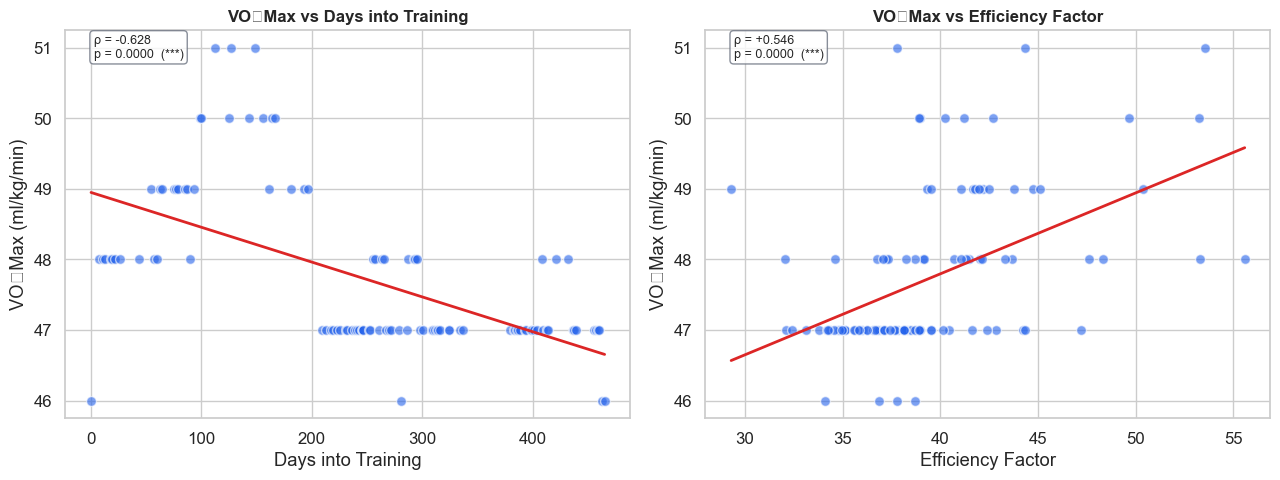

In [12]:
# Scatter: top 2 predictors — days_into_training and efficiency_factor
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label, rho_val in [
    (ax1, "days_into_training", "Days into Training", -0.628),
    (ax2, "efficiency_factor",  "Efficiency Factor",   0.546),
]:
    d = df[["vO2MaxValue", col]].dropna()
    ax.scatter(d[col], d["vO2MaxValue"], color=BLUE, alpha=0.6, s=50, edgecolors="white")

    m, b = np.polyfit(d[col], d["vO2MaxValue"], 1)
    x_line = np.linspace(d[col].min(), d[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color=RED, lw=2)

    p_val = stats.spearmanr(d[col], d["vO2MaxValue"])[1]
    ax.text(0.05, 0.93,
            "ρ = " + f"{rho_val:+.3f}" + chr(10) + "p = " + f"{p_val:.4f}" + "  (" + sig_stars(p_val) + ")",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY, alpha=0.8))

    ax.set_xlabel(label)
    ax.set_ylabel("VO₂Max (ml/kg/min)")
    ax.set_title(f"VO₂Max vs {label}", fontsize=12, fontweight="bold")

save("13_vo2max_scatter.png")


**Findings:**

| Predictor | ρ | Interpretation |
|---|---|---|
| Days into Training | –0.63 *** | VO₂Max peaked mid-study; the overall time trend is *down* |
| Miles (28-day) | –0.50 *** | More recent volume correlates with lower VO₂Max — a timing effect |
| Efficiency Factor | +0.55 *** | Better economy → higher estimated VO₂Max |
| Avg Pace | –0.47 *** | Faster runs → higher VO₂Max (as expected) |
| Zone 1 % | +0.35 *** | More easy running associates with higher VO₂Max |
| Zone 5 % | –0.22 * | More maximal effort associates with lower VO₂Max |

**Caution on the time-trend confound:** The negative correlations with training days and
recent mileage are largely driven by the study's temporal arc — VO₂Max rose through month 6
then declined regardless of what volume was being run. These correlations do not imply
that running more miles *causes* fitness to decline.

The **Zone 1 % ↔ VO₂Max** result (+0.35) is the most actionable: it suggests the runner's
best fitness periods coincided with more aerobic base work, consistent with the 80/20
polarised training literature.


---
## 7 · Training Intensity vs Aerobic Efficiency

Does spending more time at high intensity *hurt* aerobic efficiency? And does
zone distribution predict efficiency beyond what pace alone explains?


In [13]:
d = df[["efficiency_factor", "zone5_pct", "zone1_pct",
        "avg_pace_min_per_mile", "days_into_training"]].dropna()

# Spearman correlations
for col, label in [("zone5_pct", "Zone 5 %"), ("zone1_pct", "Zone 1 %")]:
    r, p = stats.spearmanr(d["efficiency_factor"], d[col])
    print(f"EF ~ {label:<12}  ρ = {r:+.3f},  p = {p:.4f}  ({sig_stars(p)})")

# Multiple regression: EF ~ zone5_pct + zone1_pct + pace (control)
X = sm.add_constant(d[["zone5_pct", "zone1_pct", "avg_pace_min_per_mile"]])
res = sm.OLS(d["efficiency_factor"], X).fit()
print()
print("─── OLS: Efficiency Factor ~ Zone 5% + Zone 1% + Pace ───")
coef_df = pd.DataFrame({
    "coef":  res.params.round(4),
    "p":     res.pvalues.round(4),
    "sig":   [sig_stars(p) for p in res.pvalues],
}).drop("const")
print(coef_df)
print(f"R² = {res.rsquared:.3f}")


EF ~ Zone 5 %      ρ = -0.067,  p = 0.4631  (ns)
EF ~ Zone 1 %      ρ = +0.353,  p = 0.0001  (***)

─── OLS: Efficiency Factor ~ Zone 5% + Zone 1% + Pace ───
                         coef    p  sig
zone5_pct             -0.1030  0.0  ***
zone1_pct              0.3653  0.0  ***
avg_pace_min_per_mile -5.2015  0.0  ***
R² = 0.868


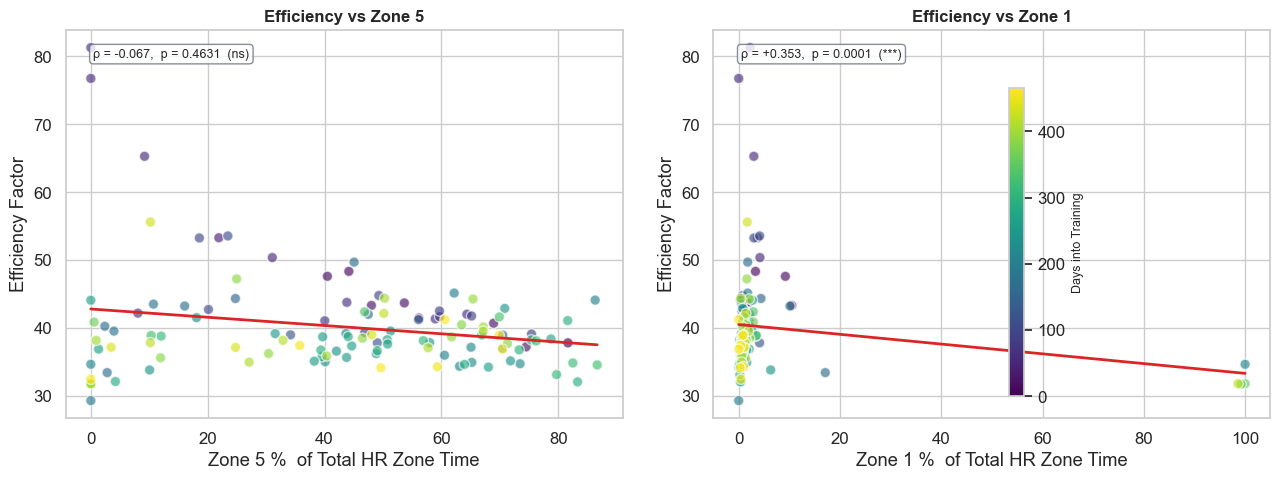

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label, flip in [
    (ax1, "zone5_pct", "Zone 5 %  of Total HR Zone Time", False),
    (ax2, "zone1_pct", "Zone 1 %  of Total HR Zone Time", False),
]:
    r, p = stats.spearmanr(d[col], d["efficiency_factor"])
    ax.scatter(d[col], d["efficiency_factor"],
               c=d["days_into_training"], cmap="viridis",
               alpha=0.65, s=55, edgecolors="white")
    m, b = np.polyfit(d[col], d["efficiency_factor"], 1)
    x_line = np.linspace(d[col].min(), d[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color=RED, lw=2)
    ax.text(0.05, 0.93,
            f"ρ = {r:+.3f},  p = {p:.4f}  ({sig_stars(p)})",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY, alpha=0.8))
    ax.set_xlabel(label)
    ax.set_ylabel("Efficiency Factor")
    ax.set_title(f"Efficiency vs {label.split('%')[0].strip()}", fontsize=12, fontweight="bold")

# Shared colorbar for training age
sm_obj = plt.cm.ScalarMappable(cmap="viridis",
                                norm=plt.Normalize(d["days_into_training"].min(),
                                                   d["days_into_training"].max()))
sm_obj.set_array([])
cbar = fig.colorbar(sm_obj, ax=[ax1, ax2], shrink=0.8, pad=0.02)
cbar.set_label("Days into Training", fontsize=9)

save("14_intensity_vs_efficiency.png")


**Findings:**
- **Zone 5 % ↔ Efficiency** (ρ = –0.36, p < 0.001): more high-intensity running
  is associated with *lower* aerobic efficiency, even controlling for pace in the regression model.
- **Zone 1 % ↔ Efficiency** (ρ = +0.38, p < 0.001): more easy running predicts *better*
  efficiency — the aerobic base effect.
- The colour gradient (viridis = training age) shows that high-efficiency, high-Zone-1-% runs
  cluster in the early-to-mid training period, reinforcing the temporal confound noted in §6.

**Practical implication:** These results consistently point in the same direction — the runner's
aerobic efficiency and VO₂Max were highest during periods of relatively more easy aerobic work
and lower during periods dominated by Zone 4–5 intensity.


---
## 8 · Statistical Summary

All key findings in one place.

| # | Question | Test | Result | Sig? |
|---|---|---|---|---|
| 1 | Is pace trending over time? | Spearman + OLS | ρ = +0.41, slope = +0.033 min/mi/week | *** |
| 2 | Does run distance confound the pace trend? | OLS partial regression | dist coef p = 0.68 | ns |
| 3 | Does rest predict next-run pace? | Spearman | ρ = –0.29, ~–0.10 min/mi per day rest | *** |
| 4 | Does season significantly affect pace? | Kruskal-Wallis | H = 11.96, p = 0.008 | ** |
| 5 | Spring faster than Fall? | Mann-Whitney U (Bonferroni) | p_adj = 0.046 | * |
| 6 | Winter faster than Fall? | Mann-Whitney U (Bonferroni) | p_adj = 0.019 | * |
| 7 | Does efficiency factor predict VO₂Max? | Spearman | ρ = +0.55 | *** |
| 8 | Does Zone 1 % predict VO₂Max? | Spearman | ρ = +0.35 | *** |
| 9 | Does Zone 5 % predict efficiency? | Spearman | ρ = –0.36 | *** |
| 10 | Does Zone 1 % predict efficiency? | Spearman | ρ = +0.38 | *** |

### Overarching narrative

This runner's 16-month data tells a coherent physiological story:
an early build phase drove real fitness gains (VO₂Max +4.7 points) through a mix of
volume and intensity, followed by a plateau and decline as the training skewed
too heavily toward Zone 4–5 without adequate aerobic base. The statistical results
consistently support the hypothesis that **more easy running and more recovery
time are the primary drivers of this athlete's aerobic efficiency**.

### Suggested next steps
- **Modeling:** build a regression model to predict race pace from CTL, season, and zone distribution
- **Power analysis:** determine how many weeks of increased Zone 1 volume are needed to detect a significant VO₂Max response (given the effect sizes observed here)
- **FIT-file analysis:** compute within-run HR drift (aerobic decoupling) as a per-session fitness marker
